# Radar Cross Section

This code is being developed to eventually plot surrounding radar data given the location of 
an in-situ research aircraft.

In [6]:
import pyart
import xarray as xr
import os
import matplotlib.pyplot as plt
import pandas as pd

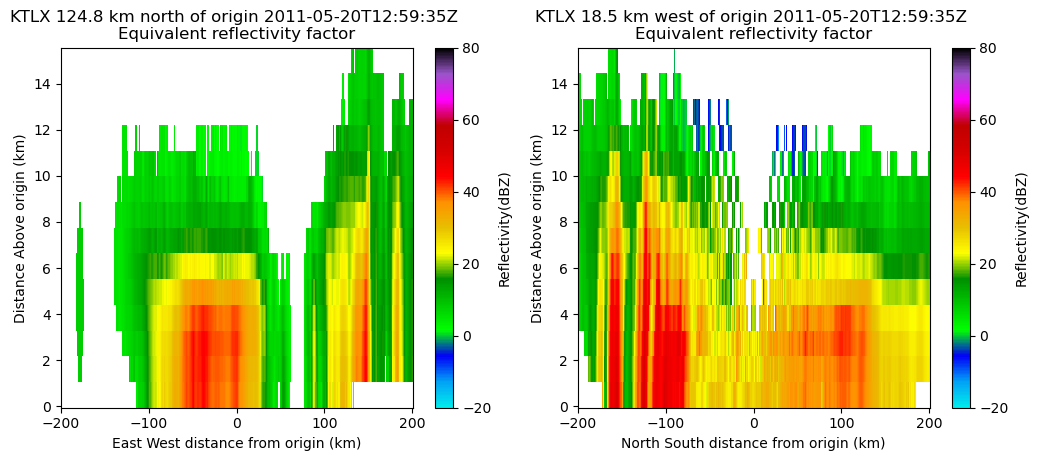

In [7]:
# Read in radar data file
filename = 'KTLX20110520_125935_V03.gz'
data = pyart.io.read('KTLX_May_20_2011/' + filename)

# Flight track over radar data plot
citation_nav = pd.read_csv('2011-05-20_CITATION.dat', sep = ',', header = None)
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]

# Convert file to cartesian coordinates

# Define grid limits 
z_grid_limits = (500., 15000.)
y_grid_limits = (-200000.,200000.)
x_grid_limits = (-200000.,200000.)

grid_resolution = 1000

def compute_number_of_points(extent, resolution):
    return int((extent[1] - extent[0])/resolution)

z_grid_points = compute_number_of_points(z_grid_limits, grid_resolution)
x_grid_points = compute_number_of_points(x_grid_limits, grid_resolution)
y_grid_points = compute_number_of_points(y_grid_limits, grid_resolution)

grid = pyart.map.grid_from_radars(data,
                                  grid_shape=(z_grid_points,
                                              y_grid_points,
                                              x_grid_points),
                                  grid_limits=(z_grid_limits,
                                               y_grid_limits,
                                               x_grid_limits),
                                 )

fig = plt.figure(figsize = (11,9))
display = pyart.graph.GridMapDisplay(grid)
time_step = 150
# Horizontal reflectivity
ax = fig.add_axes([0.53, 0.50, 0.40, 0.40])
display.plot_longitude_slice('reflectivity',
                  ax = ax,
                  lon=cit_lon[time_step],
                  vmin=-20,
                  vmax=80,
                  cmap='NWSRef')


# Vertical cross section reflectivity
ax1 = fig.add_axes([0.06, 0.50, 0.40, 0.40])
display.plot_latitude_slice('reflectivity',
                            ax = ax1,
                            lat=cit_lat[time_step],
                            vmin=-20,
                            vmax=80,
                            cmap='NWSRef')

#plt.savefig('Cross_Section_Radar2.png')